In [1]:
import pandas as pd

In [2]:
datos = pd.read_csv("ACoG_matrix.csv")

In [5]:
datos.head()

,nm,A_7_5g,A_15g,A_18g,A_22_5g
0,231.0,1.486,1.620,1.587,2.386
1,231.5,1.468,1.600,1.567,2.340
2,232.0,1.451,1.580,1.547,2.299
3,232.5,1.434,1.561,1.528,2.260
4,233.0,1.417,1.542,1.509,2.224


array([[<Axes: title={'center': 'nm'}>,
        <Axes: title={'center': 'A_7_5g'}>],
       [<Axes: title={'center': 'A_15g'}>,
        <Axes: title={'center': 'A_18g'}>],
       [<Axes: title={'center': 'A_22_5g'}>, <Axes: >]], dtype=object)

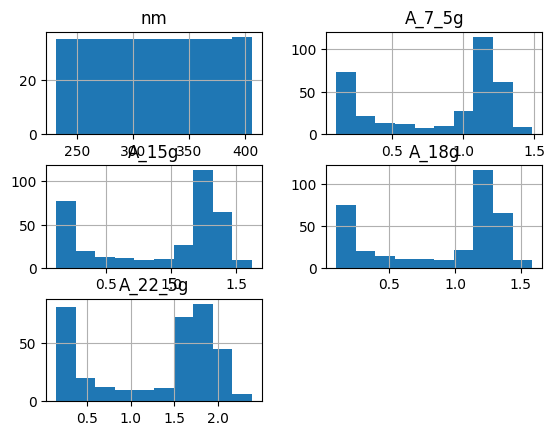

In [6]:
datos.hist()

In [7]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351 entries, 0 to 350
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   nm       351 non-null    float64
 1   A_7_5g   351 non-null    float64
 2   A_15g    351 non-null    float64
 3   A_18g    351 non-null    float64
 4   A_22_5g  351 non-null    float64
dtypes: float64(5)
memory usage: 13.8 KB


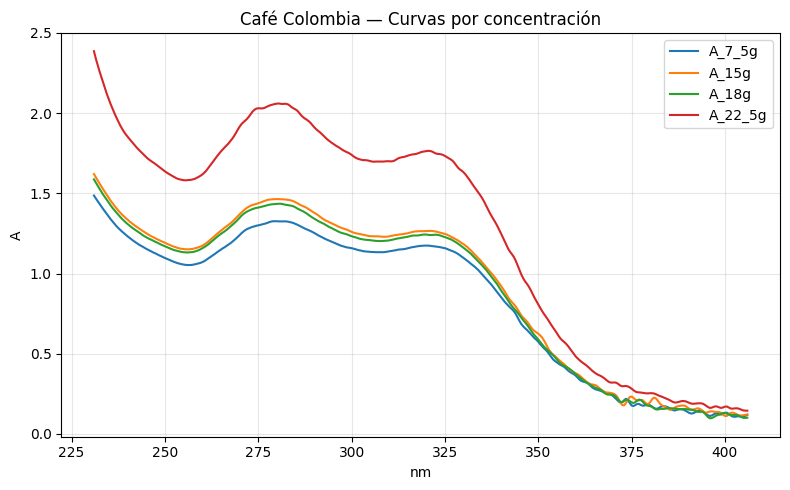

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ACoG_matrix.csv")

# Asegura numéricos y orden por nm
df["nm"] = pd.to_numeric(df["nm"], errors="coerce")
for c in ["A_7_5g","A_15g","A_18g","A_22_5g"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.sort_values("nm").reset_index(drop=True)

# Opcional: si quieres evitar cortes por NaN, filtra filas completas
plot_cols = ["A_7_5g","A_15g","A_18g","A_22_5g"]
df_plot = df[["nm"] + plot_cols].dropna(how="any")   # usa "all" si quieres permitir NaN sueltos

plt.figure(figsize=(8,5))
for col in plot_cols:
    plt.plot(df_plot["nm"], df_plot[col], label=col)
plt.xlabel("nm")
plt.ylabel("A")
plt.title("Café Colombia — Curvas por concentración")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
# plt.savefig("ACoG_curvas.png", dpi=200)
plt.show()


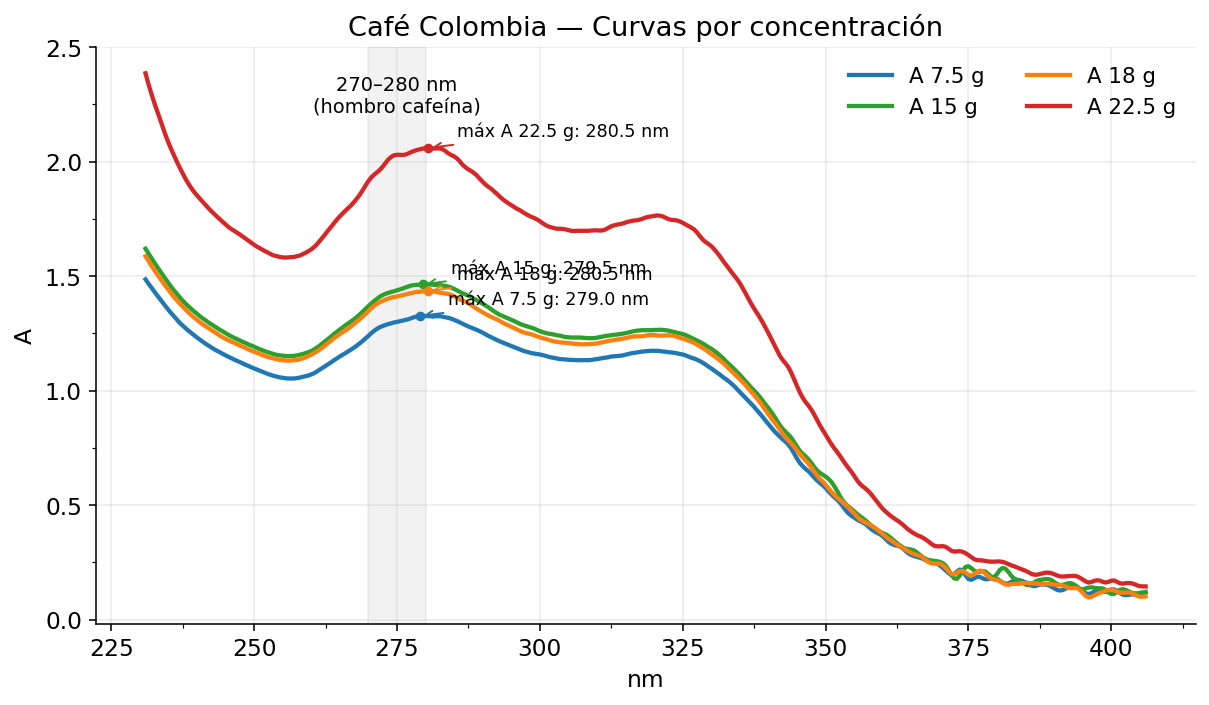

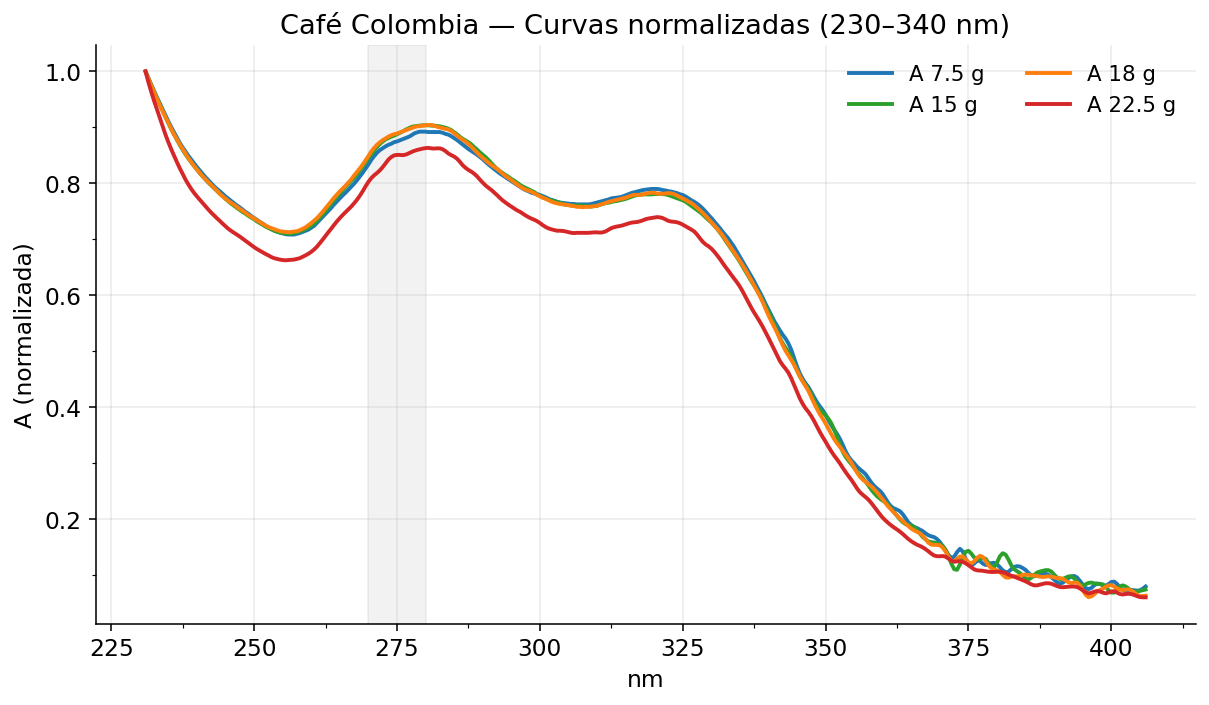

In [9]:
# === Plot bonito (publicación) para Café Colombia ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, FuncFormatter

df_plot = datos.copy()   # ya lo tienes cargado

# Columnas a graficar (en el orden que quieres)
plot_cols = ["A_7_5g", "A_15g", "A_18g", "A_22_5g"]

# --------- Estilo general ----------
plt.rcParams.update({
    "figure.figsize": (8.8, 5.2),
    "figure.dpi": 140,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Paleta y etiquetas legibles
labels = {
    "A_7_5g": "A 7.5 g",
    "A_15g":  "A 15 g",
    "A_18g":  "A 18 g",
    "A_22_5g":"A 22.5 g",
}
colors = {
    "A_7_5g": "#1f77b4",   # azul
    "A_15g":  "#2ca02c",   # verde
    "A_18g":  "#ff7f0e",   # naranja
    "A_22_5g":"#d62728",   # rojo
}

# --------- Figura 1: Curvas absolutas ----------
fig, ax = plt.subplots()

for col in plot_cols:
    ax.plot(df_plot["nm"], df_plot[col], lw=2.2, label=labels[col], color=colors[col])

# Banda sombreada (ej. hombro cafeína ~270–280 nm)
ax.axvspan(270, 280, alpha=0.10, color="gray")
ax.text(275, ax.get_ylim()[1]*0.95, "270–280 nm\n(hombro cafeína)", ha="center", va="top", fontsize=10)

# Ticks y formato
ax.set_xlabel("nm")
ax.set_ylabel("A")
ax.set_title("Café Colombia — Curvas por concentración")
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.legend(ncol=2, frameon=False, loc="upper right")

# Anotar máximos locales entre 260–320 nm (ajusta si quieres)
x = df_plot["nm"].values
mask = (x >= 260) & (x <= 320)
for col in plot_cols:
    y = df_plot[col].values
    if mask.sum() > 0:
        xm = x[mask]
        ym = y[mask]
        i = np.nanargmax(ym)
        ax.plot([xm[i]], [ym[i]], "o", ms=4, color=colors[col])
        ax.annotate(f"máx {labels[col]}: {xm[i]:.1f} nm",
                    xy=(xm[i], ym[i]),
                    xytext=(xm[i]+5, ym[i]+0.05),
                    arrowprops=dict(arrowstyle="->", lw=1, color=colors[col]),
                    fontsize=9)

fig.tight_layout()
# Guarda en alta calidad
# fig.savefig("ACoG_curvas_publicacion.png", dpi=300, bbox_inches="tight")
# fig.savefig("ACoG_curvas_publicacion.svg", bbox_inches="tight")
plt.show()

# --------- Figura 2: Curvas normalizadas (comparación de forma) ----------
fig2, ax2 = plt.subplots()

# Normalizamos por el máximo en 230–340 nm para comparar sólo la forma
mask_norm = (df_plot["nm"] >= 230) & (df_plot["nm"] <= 340)
for col in plot_cols:
    y = df_plot[col].values.astype(float)
    denom = np.nanmax(y[mask_norm]) if mask_norm.any() else np.nanmax(y)
    yn = y / denom if denom and np.isfinite(denom) else y
    ax2.plot(df_plot["nm"], yn, lw=2.0, label=labels[col], color=colors[col])

ax2.axvspan(270, 280, alpha=0.10, color="gray")
ax2.set_xlabel("nm")
ax2.set_ylabel("A (normalizada)")
ax2.set_title("Café Colombia — Curvas normalizadas (230–340 nm)")
ax2.xaxis.set_minor_locator(AutoMinorLocator(2))
ax2.yaxis.set_minor_locator(AutoMinorLocator(2))
ax2.legend(ncol=2, frameon=False, loc="upper right")
fig2.tight_layout()
# fig2.savefig("ACoG_curvas_normalizadas.png", dpi=300, bbox_inches="tight")
plt.show()


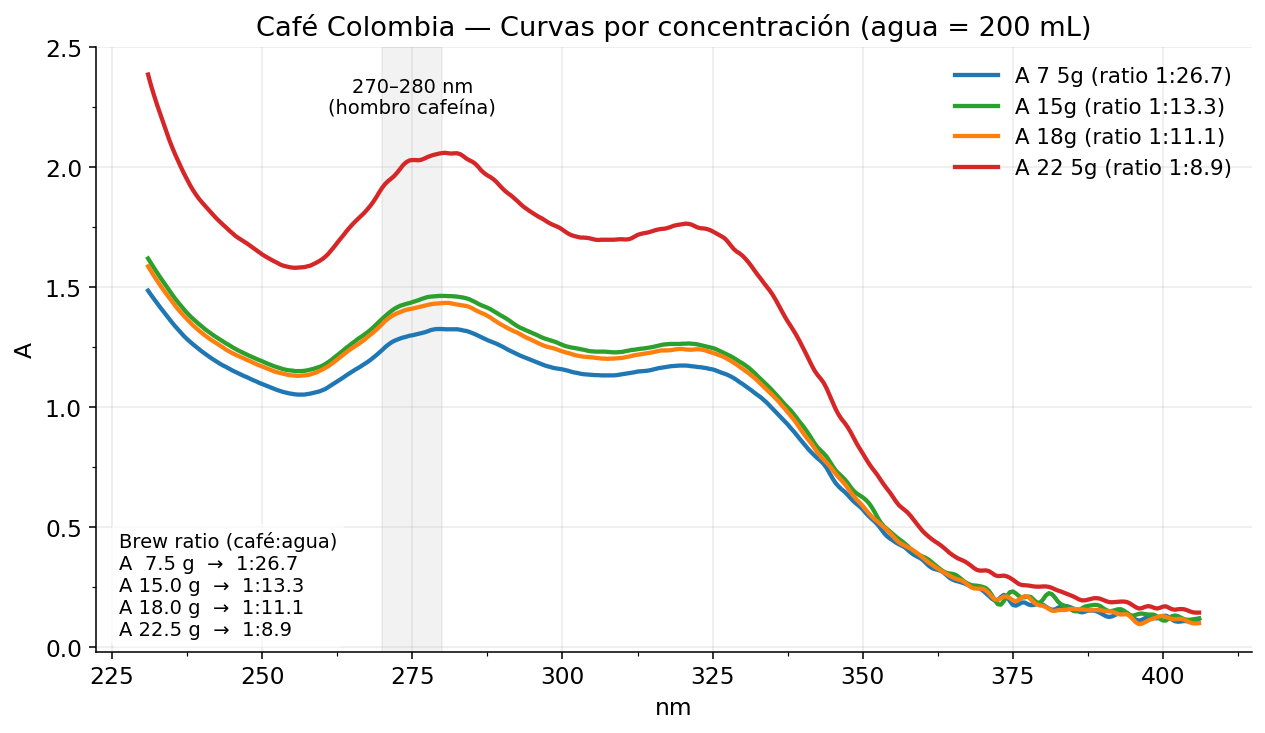

In [10]:
# === Brew ratio por curva (leyenda y recuadro) ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

df_plot = datos.copy()   # tu DataFrame con columnas: nm, A_7_5g, A_15g, A_18g, A_22_5g
plot_cols = ["A_7_5g", "A_15g", "A_18g", "A_22_5g"]

# ----- Configura el volumen de agua -----
WATER_ML = 200.0  # mL por preparación (≈ g de agua)

# Map de gramos por columna
grams_map = {"A_7_5g": 7.5, "A_15g": 15.0, "A_18g": 18.0, "A_22_5g": 22.5}

# Función ratio 1:x (café:agua)
def ratio_str(g, water_ml=WATER_ML):
    x = water_ml / g
    return f"1:{x:.1f}"

# Etiquetas con brew ratio
labels = {col: f"{col.replace('_', ' ').replace('A ', 'A ')} (ratio {ratio_str(grams_map[col])})"
          for col in plot_cols}

colors = {"A_7_5g":"#1f77b4","A_15g":"#2ca02c","A_18g":"#ff7f0e","A_22_5g":"#d62728"}

plt.rcParams.update({
    "figure.figsize": (9.2, 5.4),
    "figure.dpi": 140,
    "font.size": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots()

# Curvas
for col in plot_cols:
    ax.plot(df_plot["nm"], df_plot[col], lw=2.2, label=labels[col], color=colors[col])

# Banda caféina (270–280 nm)
ax.axvspan(270, 280, alpha=0.10, color="gray")
ax.text(275, ax.get_ylim()[1]*0.95, "270–280 nm\n(hombro cafeína)", ha="center", va="top", fontsize=10)

# Ejes y formato
ax.set_xlabel("nm")
ax.set_ylabel("A")
ax.set_title(f"Café Colombia — Curvas por concentración (agua = {WATER_ML:.0f} mL)")
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.legend(ncol=1, frameon=False, loc="upper right")

# Recuadro con ratios ordenados por gramaje
rat_lines = [f"A {g:>4.1f} g  →  {ratio_str(g)}" for g in [7.5, 15.0, 18.0, 22.5]]
bbox_txt = "Brew ratio (café:agua)\n" + "\n".join(rat_lines)
ax.text(0.02, 0.02, bbox_txt, transform=ax.transAxes,
        ha="left", va="bottom", fontsize=10,
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", boxstyle="round,pad=0.4"))

plt.tight_layout()
# fig.savefig("ACoG_curvas_con_ratio.png", dpi=300, bbox_inches="tight")
plt.show()


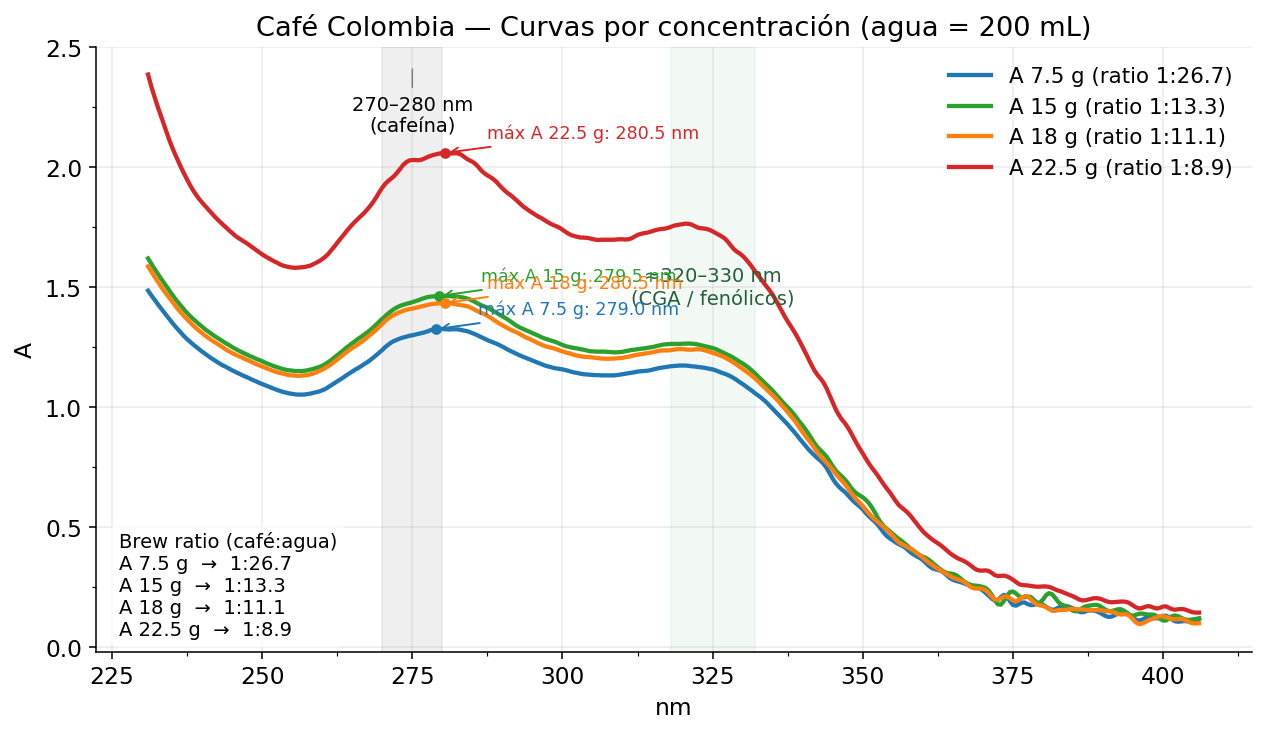

In [13]:
# === Plot publicación con brew ratio + anotaciones de compuestos ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

df_plot = datos.copy()  # columnas: nm, A_7_5g, A_15g, A_18g, A_22_5g
plot_cols = ["A_7_5g", "A_15g", "A_18g", "A_22_5g"]

# ----- Parámetros de extracción -----
WATER_ML = 200.0  # mL de agua usados en todos los casos
grams_map = {"A_7_5g": 7.5, "A_15g": 15.0, "A_18g": 18.0, "A_22_5g": 22.5}

def ratio_str(g, water_ml=WATER_ML):
    x = water_ml / g
    return f"1:{x:.1f}"

# Etiquetas de leyenda con ratios
pretty = {"A_7_5g":"A 7.5 g", "A_15g":"A 15 g", "A_18g":"A 18 g", "A_22_5g":"A 22.5 g"}
labels = {c: f"{pretty[c]} (ratio {ratio_str(grams_map[c])})" for c in plot_cols}

# Colores coherentes
colors = {"A_7_5g":"#1f77b4","A_15g":"#2ca02c","A_18g":"#ff7f0e","A_22_5g":"#d62728"}

# Estética global
plt.rcParams.update({
    "figure.figsize": (9.2, 5.4),
    "figure.dpi": 140,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, ax = plt.subplots()

# Curvas
for c in plot_cols:
    ax.plot(df_plot["nm"], df_plot[c], lw=2.2, label=labels[c], color=colors[c])

# === Sombras de regiones relevantes ===
# Cafeína 270–280 nm
ax.axvspan(270, 280, color="gray", alpha=0.12)
ax.annotate("270–280 nm\n(cafeína)",
            xy=(275, ax.get_ylim()[1]*0.97),
            xytext=(275, ax.get_ylim()[1]*0.92),
            ha="center", va="top", fontsize=10,
            arrowprops=dict(arrowstyle="-", lw=0.8, color="gray"))

# CGA ~320–330 nm (ancha, fenólicos)
ax.axvspan(318, 332, color="#88c999", alpha=0.10)
ax.text(325, ax.get_ylim()[1]*0.60, "≈320–330 nm\n(CGA / fenólicos)",
        ha="center", va="center", fontsize=10, color="#245f38")

# === Flechitas a máximos locales entre 260–320 nm (uno por curva) ===
x = df_plot["nm"].to_numpy()
mask = (x >= 260) & (x <= 320)

def mark_local_peak(x, y, color, label):
    xm, ym = x[mask], y[mask]
    if not np.any(np.isfinite(ym)): return
    i = np.nanargmax(ym)
    ax.plot([xm[i]], [ym[i]], "o", ms=4.5, color=color, zorder=5)
    ax.annotate(f"máx {label.split('(')[0].strip()}: {xm[i]:.1f} nm",
                xy=(xm[i], ym[i]),
                xytext=(xm[i]+7, ym[i]+0.06),
                fontsize=9,
                arrowprops=dict(arrowstyle="->", lw=1.0, color=color),
                color=color)

for c in plot_cols:
    mark_local_peak(x, df_plot[c].to_numpy(dtype=float), colors[c], labels[c])

# Ejes/leyenda
ax.set_xlabel("nm")
ax.set_ylabel("A")
ax.set_title(f"Café Colombia — Curvas por concentración (agua = {WATER_ML:.0f} mL)")
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.legend(loc="upper right", frameon=False, ncol=1)

# Recuadro con ratios (ordenado por gramos)
rat_lines = [f"{pretty[c]:>6}  →  {ratio_str(grams_map[c])}" for c in ["A_7_5g","A_15g","A_18g","A_22_5g"]]
ax.text(0.02, 0.02, "Brew ratio (café:agua)\n" + "\n".join(rat_lines),
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10,
        bbox=dict(facecolor="white", alpha=0.72, edgecolor="none", boxstyle="round,pad=0.4"))

fig.tight_layout()
# fig.savefig("ACoG_curvas_con_ratio_y_anotaciones.png", dpi=300, bbox_inches="tight")
plt.show()



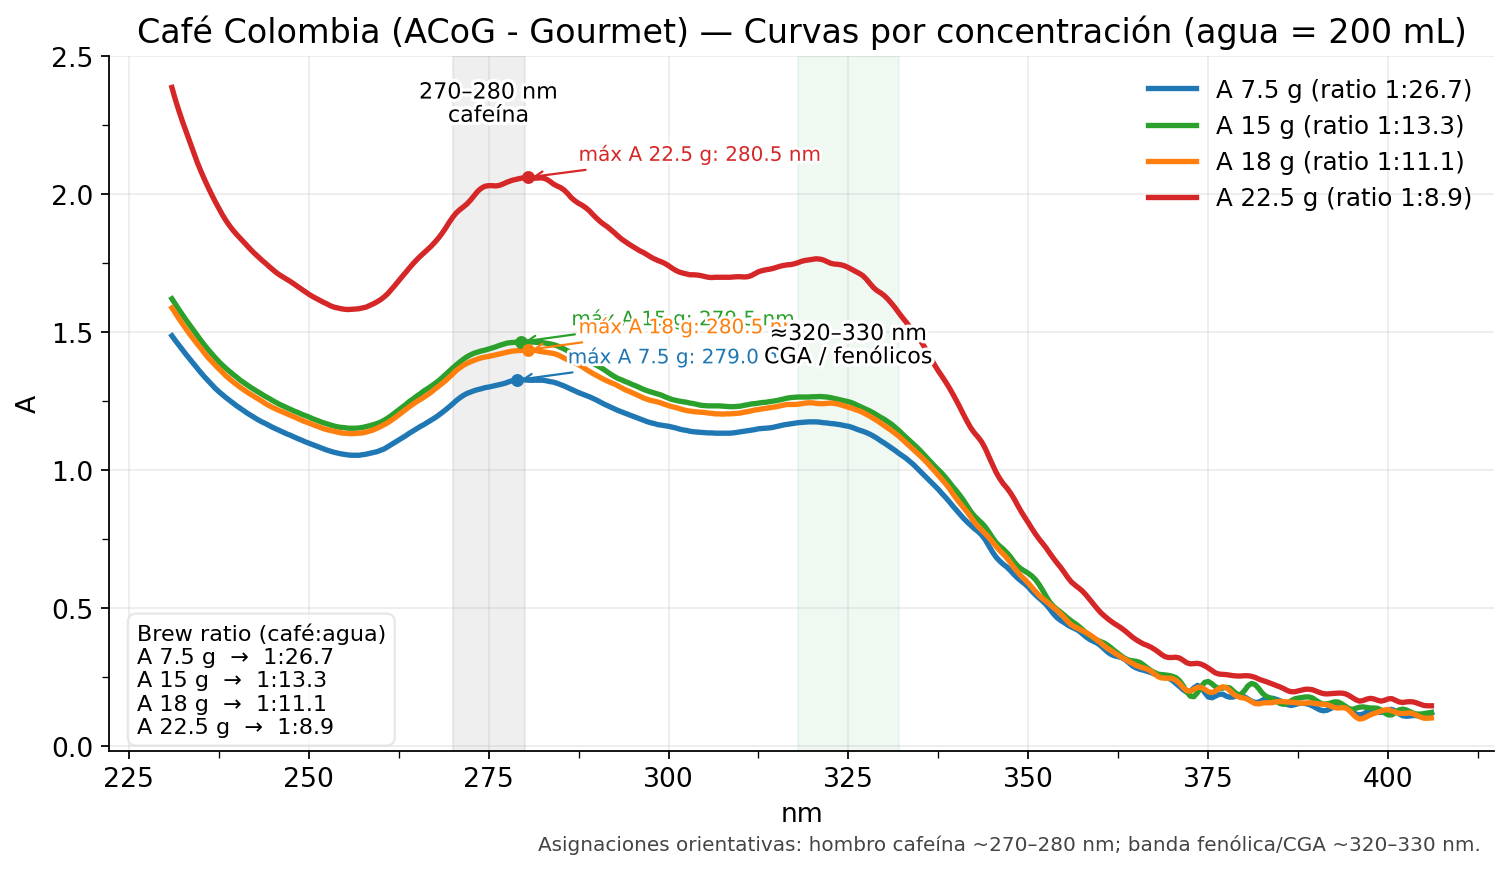

In [21]:
# === Plot publicación (pro) con brew ratio + anotaciones de compuestos ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import matplotlib.patheffects as pe

df_plot = datos.copy()
plot_cols = ["A_7_5g", "A_15g", "A_18g", "A_22_5g"]

# ----- Parámetros de extracción -----
WATER_ML = 200.0  # mL por extracción
grams_map = {"A_7_5g": 7.5, "A_15g": 15.0, "A_18g": 18.0, "A_22_5g": 22.5}

def ratio_str(g):
    return f"1:{WATER_ML/g:.1f}"

pretty = {"A_7_5g":"A 7.5 g", "A_15g":"A 15 g", "A_18g":"A 18 g", "A_22_5g":"A 22.5 g"}
labels = {c: f"{pretty[c]} (ratio {ratio_str(grams_map[c])})" for c in plot_cols}

# Paleta consistente
colors = {"A_7_5g":"#1f77b4","A_15g":"#2ca02c","A_18g":"#ff7f0e","A_22_5g":"#d62728"}

# Estética global sobria
plt.rcParams.update({
    "figure.figsize": (9.6, 5.6),
    "figure.dpi": 160,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.23,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
})

fig, ax = plt.subplots()

# Curvas
for c in plot_cols:
    ax.plot(df_plot["nm"], df_plot[c], lw=2.4, label=labels[c], color=colors[c], zorder=2)

# === Bandas espectrales de interés (sombras suaves) ===
# Cafeína ~270–280 nm
ax.axvspan(270, 280, color="gray", alpha=0.12, zorder=0)
# Fenólicos/CGA ~320–330 nm
ax.axvspan(318, 332, color="#8acc9a", alpha=0.12, zorder=0)

# Etiquetas de bandas (con trazo blanco para legibilidad)
def band_label(x, y, text, color="black"):
    txt = ax.text(x, y, text, ha="center", va="center", fontsize=10, color=color, zorder=5)
    txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

ylim = ax.get_ylim()
band_label(275, ylim[1]*0.93, "270–280 nm\ncafeína")
band_label(325, ylim[1]*0.58, "≈320–330 nm\nCGA / fenólicos")

# === Flechas a máximos locales (260–320 nm) en cada curva ===
x = df_plot["nm"].to_numpy()
mask = (x >= 260) & (x <= 320)

def mark_local_peak(y, color, name_for_text):
    xm, ym = x[mask], y[mask]
    if not np.any(np.isfinite(ym)): return
    i = np.nanargmax(ym)
    ax.plot(xm[i], ym[i], "o", ms=4.8, color=color, zorder=6)
    ax.annotate(f"máx {name_for_text}: {xm[i]:.1f} nm",
                xy=(xm[i], ym[i]),
                xytext=(xm[i] + 7, ym[i] + 0.06),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle="->", lw=1.0, color=color),
                path_effects=[pe.withStroke(linewidth=2.5, foreground="white")])

for c in plot_cols:
    mark_local_peak(df_plot[c].to_numpy(dtype=float), colors[c], pretty[c])

# Ejes, ticks, leyenda
ax.set_xlabel("nm")
ax.set_ylabel("A")
ax.set_title(f"Café Colombia (ACoG - Gourmet) — Curvas por concentración (agua = {WATER_ML:.0f} mL)")
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which="minor", length=3)

leg = ax.legend(loc="upper right", frameon=False, ncol=1)

# Recuadro con ratios ordenados
rat_lines = [f"{pretty[c]:>6}  →  {ratio_str(grams_map[c])}" for c in ["A_7_5g","A_15g","A_18g","A_22_5g"]]
ax.text(0.02, 0.02, "Brew ratio (café:agua)\n" + "\n".join(rat_lines),
        transform=ax.transAxes, ha="left", va="bottom", fontsize=10,
        bbox=dict(facecolor="white", alpha=0.75, edgecolor="#e0e0e0", boxstyle="round,pad=0.4"))

# Nota de pie discreta (origen de asignaciones)
ax.text(0.99, -0.12,
        "Asignaciones orientativas: hombro cafeína ~270–280 nm; banda fenólica/CGA ~320–330 nm.",
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#444444")

fig.tight_layout()
fig.savefig("ACoG_curvas_publicacion_pro.png", dpi=300)
plt.show()


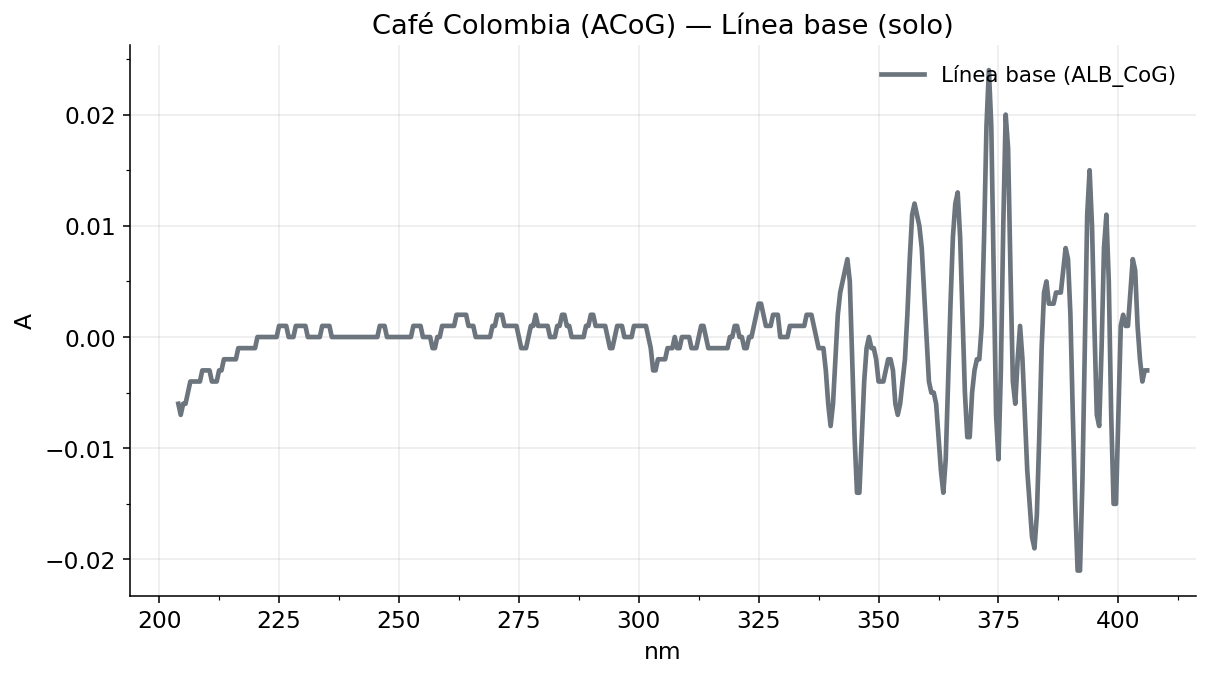

In [20]:
# === Graficar SOLO la línea base (ALB_CoG_clean.csv) ===
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# Toggle para mostrar/ocultar banda de cafeína
SHOW_CAFFEINE_BAND = False  # <— pon True si la quieres

# 1) localizar el archivo limpio de línea base (busca en subcarpetas)
candidates = list(Path(".").glob("**/ALB_CoG_clean.csv"))
if not candidates:
    raise FileNotFoundError("No encontré ALB_CoG_clean.csv. Revisa que ya exista el 'clean' en ALB_CoG/")
base_csv = candidates[0]

# 2) cargar
base = pd.read_csv(base_csv)   # columnas: nm, A

# 3) estilo
plt.rcParams.update({
    "figure.figsize": (8.8, 5.0),
    "figure.dpi": 140,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# 4) plot
fig, ax = plt.subplots()
ax.plot(base["nm"], base["A"], lw=2.4, color="#6c757d", label="Línea base (ALB_CoG)")

# (opcional) banda 270–280 nm — AHORA DESACTIVADA
if SHOW_CAFFEINE_BAND:
    ax.axvspan(270, 280, color="gray", alpha=0.12)

# formato
ax.set_xlabel("nm")
ax.set_ylabel("A")
ax.set_title("Café Colombia (ACoG) — Línea base (solo)")
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.legend(frameon=False, loc="upper right")

fig.tight_layout()
fig.savefig("ACoG_linea_base.png", dpi=300, bbox_inches="tight")
plt.show()
